In [ ]:
import os
import warnings
from datetime import datetime
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

print('Imports listos.')

# Grid Search para SARIMA

Este notebook busca hiperparametros para el modelo de series temporales del proyecto de demanda hospitalaria.

Estrategia:
- Entrenar con 2014-2023.
- Validar con 2024.
- Reentrenar con 2014-2024 usando el mejor resultado.
- Evaluar el modelo final sobre 2025.

Se usa SARIMA porque el proyecto trabaja con una serie semanal con estacionalidad anual (52 semanas).

In [ ]:
DATA_PATH = '../dataset/at_urg_respiratorio_2026-05-10.parquet'
RESULTS_DIR = '../resultados'


def get_date_from_iso_week(year, week):
    date_str = f'{year}-W{week:02d}-1'
    try:
        return datetime.strptime(date_str, '%G-W%V-%u')
    except ValueError:
        return datetime(year, 12, 31)


def load_weekly_series(data_path):
    if not os.path.exists(data_path):
        raise FileNotFoundError(
            f'No se encontro el archivo de datos en: {data_path}. Revisa la ruta relativa desde notebooks/grid_search.ipynb.'
        )

    df = pd.read_parquet(data_path)
    df['Fecha'] = df.apply(lambda row: get_date_from_iso_week(int(row['Anio']), int(row['SemanaEstadistica'])), axis=1)

    ts_df = df.groupby('Fecha')['NumTotal'].sum().reset_index()
    ts_df.set_index('Fecha', inplace=True)
    ts_df.sort_index(inplace=True)
    ts_df = ts_df.asfreq('W-MON')
    ts_df['NumTotal'] = ts_df['NumTotal'].interpolate(method='linear')
    return ts_df


ts_df = load_weekly_series(DATA_PATH)
print('Serie cargada:')
display(ts_df.head())
print(f'Rango: {ts_df.index.min().date()} -> {ts_df.index.max().date()}')
print(f'Registros: {len(ts_df)}')

In [8]:
# Separacion temporal para evitar leakage
train_full = ts_df[(ts_df.index.year >= 2014) & (ts_df.index.year <= 2024)].copy()
train = ts_df[(ts_df.index.year >= 2014) & (ts_df.index.year <= 2023)].copy()
validation = ts_df[ts_df.index.year == 2024].copy()
test = ts_df[ts_df.index.year == 2025].copy()

print(f'Train: {train.index.min().date()} -> {train.index.max().date()} | n={len(train)}')
print(f'Validation: {validation.index.min().date()} -> {validation.index.max().date()} | n={len(validation)}')
print(f'Test: {test.index.min().date()} -> {test.index.max().date()} | n={len(test)}')

Train: 2014-01-06 -> 2023-12-25 | n=521
Validation: 2024-01-01 -> 2024-12-30 | n=53
Test: 2025-01-06 -> 2025-12-29 | n=52


In [12]:
# Grid search acotado para SARIMA
p_values = [0, 1, 2]
d_values = [0]
q_values = [0, 1, 2]
P_values = [0, 1]
D_values = [1]
Q_values = [0, 1]
m = 52

search_results = []

for order in product(p_values, d_values, q_values):
    for seasonal_order in product(P_values, D_values, Q_values):
        seasonal_order = (*seasonal_order, m)
        try:
            model = SARIMAX(
                train['NumTotal'],
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False,
            )
            fitted = model.fit(disp=False, maxiter=50)
            pred = fitted.get_forecast(steps=len(validation)).predicted_mean

            rmse = np.sqrt(mean_squared_error(validation['NumTotal'], pred))
            mae = mean_absolute_error(validation['NumTotal'], pred)
            mape = mean_absolute_percentage_error(validation['NumTotal'], pred)

            search_results.append({
                'order': order,
                'seasonal_order': seasonal_order,
                'aic': fitted.aic,
                'bic': fitted.bic,
                'rmse_val': rmse,
                'mae_val': mae,
                'mape_val': mape,
            })
        except Exception as error:
            search_results.append({
                'order': order,
                'seasonal_order': seasonal_order,
                'aic': np.nan,
                'bic': np.nan,
                'rmse_val': np.nan,
                'mae_val': np.nan,
                'mape_val': np.nan,
                'error': str(error),
            })

results_df = pd.DataFrame(search_results)
results_df = results_df.sort_values(['rmse_val', 'aic'], na_position='last').reset_index(drop=True)

os.makedirs(RESULTS_DIR, exist_ok=True)
results_path = os.path.join(RESULTS_DIR, 'grid_search_sarima.csv')
results_df.to_csv(results_path, index=False)

top10_df = results_df.head(10)
top10_path = os.path.join(RESULTS_DIR, 'grid_search_sarima_top10.csv')
top10_df.to_csv(top10_path, index=False)

best_row = results_df.iloc[0]
print('Mejor combinacion por RMSE de validacion:')
print(f"order={tuple(best_row['order'])}, seasonal_order={tuple(best_row['seasonal_order'])}, RMSE={best_row['rmse_val']:.2f}, MAE={best_row['mae_val']:.2f}, MAPE={best_row['mape_val']*100:.2f}%")
print(f'Resultados completos guardados en: {results_path}')
print(f'Top 10 guardado en: {top10_path}')

Mejor combinacion por RMSE de validacion:
order=(1, 0, 0), seasonal_order=(0, 1, 0, 52), RMSE=33042.78, MAE=27265.04, MAPE=15.49%
Resultados completos guardados en: ../resultados\grid_search_sarima.csv
Top 10 guardado en: ../resultados\grid_search_sarima_top10.csv


In [10]:
best_row = results_df.iloc[0]
best_order = tuple(best_row['order'])
best_seasonal_order = tuple(best_row['seasonal_order'])

print(f'Best order: {best_order}')
print(f'Best seasonal order: {best_seasonal_order}')
print(f'Validation RMSE: {best_row["rmse_val"]:.2f}')
print(f'Validation MAE: {best_row["mae_val"]:.2f}')
print(f'Validation MAPE: {best_row["mape_val"]*100:.2f}%')

best_model = SARIMAX(
    train_full['NumTotal'],
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
final_results = best_model.fit(disp=False, maxiter=100)
print(final_results.summary())

final_forecast = final_results.get_forecast(steps=len(test))
final_pred = final_forecast.predicted_mean
final_ci = final_forecast.conf_int()

rmse_test = np.sqrt(mean_squared_error(test['NumTotal'], final_pred))
mae_test = mean_absolute_error(test['NumTotal'], final_pred)
mape_test = mean_absolute_percentage_error(test['NumTotal'], final_pred)

print('\nMetricas finales sobre test:')
print(f'RMSE: {rmse_test:.2f}')
print(f'MAE:  {mae_test:.2f}')
print(f'MAPE: {mape_test*100:.2f}%')

Best order: (1, 0, 0)
Best seasonal order: (0, 1, 0, 52)
Validation RMSE: 33042.78
Validation MAE: 27265.04
Validation MAPE: 15.49%
                                     SARIMAX Results                                      
Dep. Variable:                           NumTotal   No. Observations:                  574
Model:             SARIMAX(1, 0, 0)x(0, 1, 0, 52)   Log Likelihood               -5995.751
Date:                            Wed, 17 Jun 2026   AIC                          11995.502
Time:                                    20:17:41   BIC                          12004.013
Sample:                                01-06-2014   HQIC                         11998.836
                                     - 12-30-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------

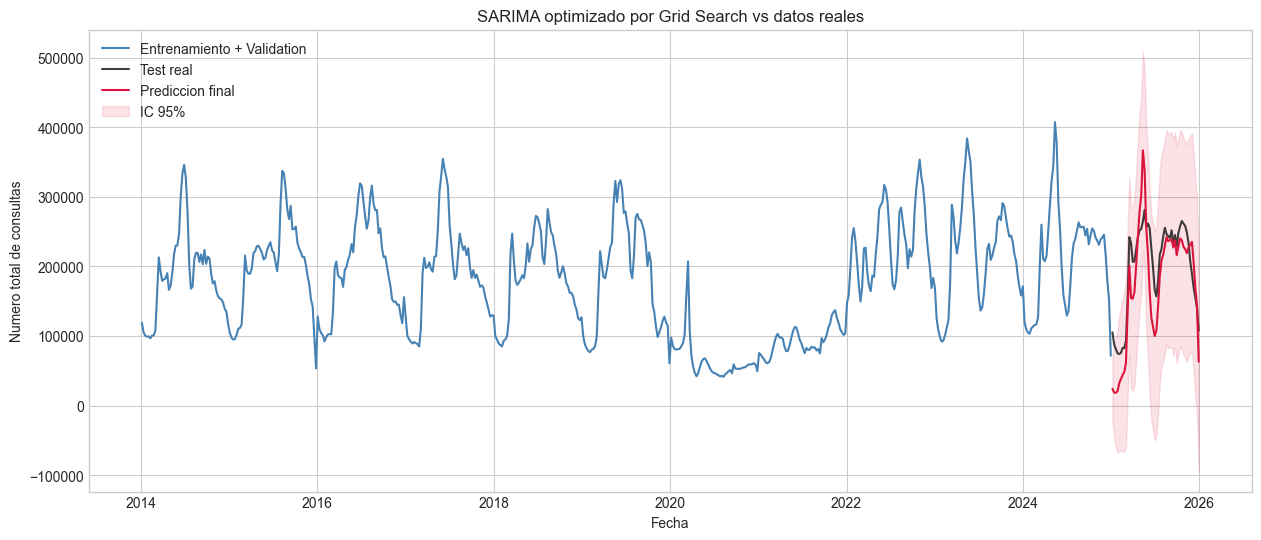

Predicciones guardadas en: ../resultados\grid_search_sarima_predicciones_test.csv


In [11]:
plt.figure(figsize=(15, 6))

plt.plot(train_full.index, train_full['NumTotal'], label='Entrenamiento + Validation', color='steelblue')
plt.plot(test.index, test['NumTotal'], label='Test real', color='black', alpha=0.75)
plt.plot(final_pred.index, final_pred, label='Prediccion final', color='crimson')
plt.fill_between(final_ci.index, final_ci.iloc[:, 0], final_ci.iloc[:, 1], color='crimson', alpha=0.12, label='IC 95%')

plt.title('SARIMA optimizado por Grid Search vs datos reales')
plt.xlabel('Fecha')
plt.ylabel('Numero total de consultas')
plt.legend()
plt.grid(True)
plt.show()

final_output = pd.DataFrame({
    'Fecha': test.index,
    'Real': test['NumTotal'].values,
    'Prediccion': final_pred.values,
})
final_output_path = os.path.join(RESULTS_DIR, 'grid_search_sarima_predicciones_test.csv')
final_output.to_csv(final_output_path, index=False)
print(f'Predicciones guardadas en: {final_output_path}')

## Validation Curves

Estas curvas muestran cómo cambia el **RMSE de validación** al variar cada hiperparámetro del modelo SARIMA (`p`, `q`, `P` y `Q`). Se construyen a partir de los resultados obtenidos en el Grid Search.


In [ ]:
import matplotlib.pyplot as plt
import ast

# Si se cargó results_df desde CSV, convertir texto a tuplas
if isinstance(results_df["order"].iloc[0], str):
    results_df["order"] = results_df["order"].apply(ast.literal_eval)
if isinstance(results_df["seasonal_order"].iloc[0], str):
    results_df["seasonal_order"] = results_df["seasonal_order"].apply(ast.literal_eval)

def plot_validation_curve(df, param_name, extractor, title):
    temp = df.copy()
    temp[param_name] = temp.apply(extractor, axis=1)
    curve = temp.groupby(param_name)["rmse_val"].mean().reset_index()
    plt.figure(figsize=(6,4))
    plt.plot(curve[param_name], curve["rmse_val"], marker="o")
    plt.title(title)
    plt.xlabel(param_name)
    plt.ylabel("RMSE de validación")
    plt.grid(True)
    plt.show()

plot_validation_curve(results_df, "p",
                      lambda r: r["order"][0],
                      "Validation Curve - p")

plot_validation_curve(results_df, "q",
                      lambda r: r["order"][2],
                      "Validation Curve - q")

plot_validation_curve(results_df, "P",
                      lambda r: r["seasonal_order"][0],
                      "Validation Curve - P")

plot_validation_curve(results_df, "Q",
                      lambda r: r["seasonal_order"][2],
                      "Validation Curve - Q")
